#🎯 Job Acceptance Prediction System

##Objective: Predict whether a candidate will accept or reject a job offer using machine learning.

##Dataset:
https://drive.google.com/file/d/1h7IY0sNyW7tDoI03nO4lohiYk04o0Hqd/view?usp=sharing

##Import Packages

In [11]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train-Test Split
from sklearn.model_selection import train_test_split

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve
)

# Model Saving
import joblib

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

##Data loading

In [12]:
df = pd.read_csv("/content/HR_Job_Placement_Dataset.csv")
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,2,No,1,Willing,Relevant,3.530557,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,1,yes,0,Not Willing,Relevant,9.858155,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,1,Yes,1,Willing,Relevant,5.801817,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,2,No,0,Not Willing,Relevant,2.129805,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,1,No,0,Willing,Not Relevant,7.948314,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


##Dataset Overview

In [13]:
df.shape

(51500, 26)

In [14]:
print("Column Names")
print(df.columns.tolist())

Column Names
['age_years', 'gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'degree_specialization', 'technical_score', 'aptitude_score', 'communication_score', 'skills_match_percentage', 'certifications_count', 'internship_experience', 'years_of_experience', 'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa', 'expected_ctc_lpa', 'company_tier', 'job_role_match', 'competition_level', 'bond_requirement', 'notice_period_days', 'layoff_history', 'employment_gap_months', 'relocation_willingness', 'status']


In [15]:
print("Data Types")
print(df.dtypes)

Data Types
age_years                      int64
gender                        object
ssc_percentage               float64
hsc_percentage               float64
degree_percentage            float64
degree_specialization         object
technical_score              float64
aptitude_score               float64
communication_score          float64
skills_match_percentage      float64
certifications_count           int64
internship_experience         object
years_of_experience            int64
career_switch_willingness     object
relevant_experience           object
previous_ctc_lpa             float64
expected_ctc_lpa             float64
company_tier                  object
job_role_match                object
competition_level             object
bond_requirement              object
notice_period_days           float64
layoff_history                object
employment_gap_months        float64
relocation_willingness        object
status                        object
dtype: object


In [16]:
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness 

In [17]:
print("Statistical Summary")
df.describe().T

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
age_years,51500.0,27.505456,4.025385,21.0,24.000000,27.000000,31.000000,34.000000
ssc_percentage,48919.0,70.002505,7.976314,50.0,64.574733,69.971210,75.389057,95.000000
hsc_percentage,49435.0,72.060636,7.916654,50.0,66.720058,72.014383,77.389894,95.000000
degree_percentage,51500.0,74.010825,6.945579,55.0,69.305041,73.998187,78.707827,95.000000
technical_score,51500.0,68.027499,11.855145,40.0,59.935988,67.986042,76.049235,100.000000
aptitude_score,51500.0,64.005715,9.922397,40.0,57.204237,63.972079,70.727134,100.000000
communication_score,51500.0,66.106692,9.907488,45.0,59.252271,66.033268,72.840985,100.000000
skills_match_percentage,51500.0,73.937491,11.794258,45.0,65.851924,74.001772,82.112773,100.000000
certifications_count,51500.0,1.400136,1.184387,0.0,1.000000,1.000000,2.000000,8.000000
years_of_experience,51500.0,1.494117,1.375508,0.0,0.000000,1.000000,2.000000,5.000000


In [18]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
age_years                       0
gender                          0
ssc_percentage               2581
hsc_percentage               2065
degree_percentage               0
degree_specialization           0
technical_score                 0
aptitude_score                  0
communication_score             0
skills_match_percentage         0
certifications_count            0
internship_experience           0
years_of_experience             0
career_switch_willingness    8466
relevant_experience          8426
previous_ctc_lpa                0
expected_ctc_lpa                0
company_tier                    0
job_role_match               6131
competition_level               0
bond_requirement                0
notice_period_days           1582
layoff_history               8467
employment_gap_months        1097
relocation_willingness       8475
status                          0
dtype: int64


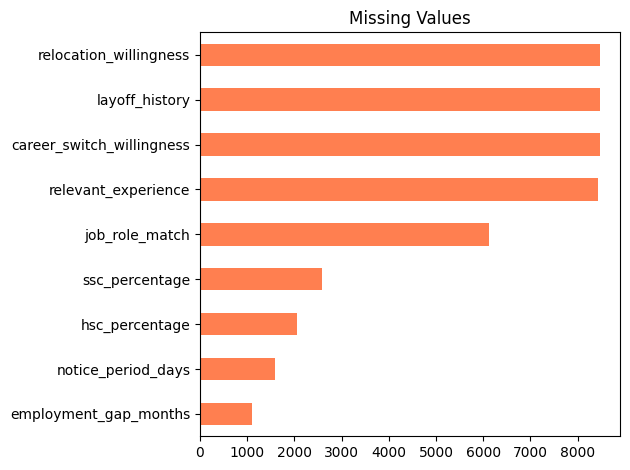

In [22]:
# Missing Values
missing = df.isnull().sum()
missing[missing > 0].sort_values().plot(kind='barh', color='coral')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

##Insights

*   24,000+ missing values require imputation before ML modeling.

*   Layoff History (6,200) and Willingness columns (5,700+) have the highest   missing rates.

*   Interview scores (0 missing) are the most complete features.

*  Categorical columns need mode imputation; numerical columns need median imputation.

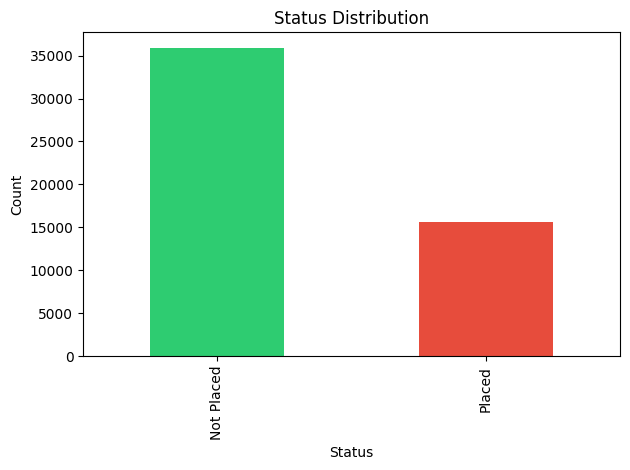

In [19]:
#Target Distribution
df['status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##Insights

*  Not Placed candidates (27,000+) significantly outnumber Placed candidates (12,000+), indicating class imbalance in the dataset

*  The dataset is imbalanced with a 70:30 ratio, requiring techniques like SMOTE or class weighting for effective ML modeling

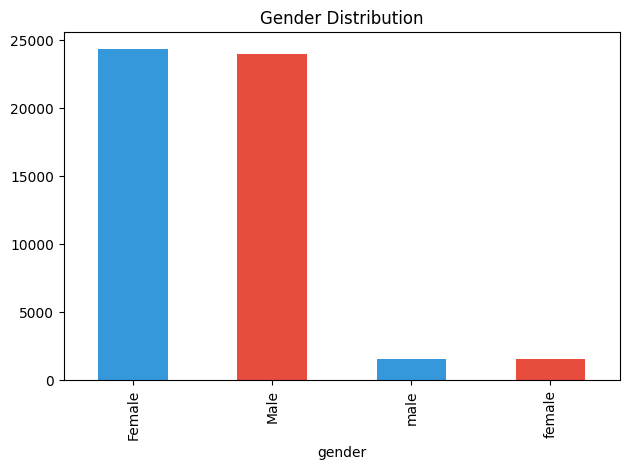

In [20]:
#Gender Distribution
df['gender'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

##Insights


*   Male candidates (19,000+) significantly outnumber Female candidates (14,000+), indicating gender imbalance in the dataset

*   The dataset has a 57:43 male-to-female ratio, which should be considered for fair model evaluation across gender groups.

*   Data Inconsistency: Gender values appear in mixed cases ("male", "female", "Male", "Female"), requiring standardization to a single format before analysis.

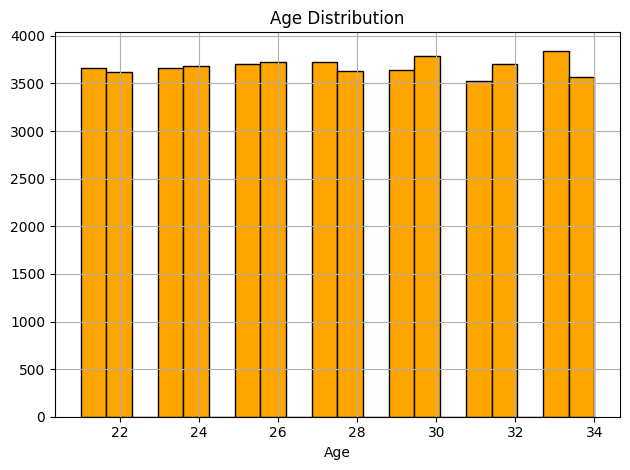

In [21]:
#Age
df['age_years'].hist(bins=20, color='orange', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.tight_layout()
plt.show()


##Insights


*   Candidates are predominantly in the 25-30 age group, with peak frequency around age 27

*   The distribution is roughly normal (bell-shaped), indicating a healthy spread of candidate ages without significant outliers


*   Age data shows good consistency with no apparent missing or erroneous values across the range

##Data Cleaning & Preprocessing

### 1. REMOVE DUPLICATES

In [23]:
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (50124, 26)


### 2. HANDLE MISSING VALUES

In [24]:
# Categorical: Fill with mode (most frequent)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical: Fill with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

Missing values after cleaning: 0


### 3. CORRECT INCONSISTENT CATEGORICAL LABELS

In [25]:
# Standardize Yes/No
yes_no_map = {'Yes': 'Yes', 'yes': 'Yes', 'YES': 'Yes', 'y': 'Yes', 'Y': 'Yes',
              'No': 'No', 'no': 'No', 'NO': 'No', 'n': 'No', 'N': 'No'}

for col in ['internship_experience', 'layoff_history', 'bond_requirement']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()
        df[col] = df[col].map(yes_no_map).fillna(df[col])

# Standardize Gender
gender_map = {'Male': 'Male', 'male': 'Male', 'M': 'Male', 'm': 'Male',
              'Female': 'Female', 'female': 'Female', 'F': 'Female', 'f': 'Female'}
if 'gender' in df.columns:
    df['gender'] = df['gender'].astype(str).str.strip().str.title()
    df['gender'] = df['gender'].map(gender_map).fillna(df['gender'])

# Standardize Company Tier
if 'company_tier' in df.columns:
    df['company_tier'] = df['company_tier'].astype(str).str.strip()
    df['company_tier'] = df['company_tier'].str.replace('Tier 1 ', 'Tier 1')
    df['company_tier'] = df['company_tier'].str.replace('Tier 2 ', 'Tier 2')
    df['company_tier'] = df['company_tier'].str.replace('Tier 3 ', 'Tier 3')

# Standardize Status
if 'status' in df.columns:
    df['status'] = df['status'].astype(str).str.strip().str.title()

print("✅ Categorical labels standardized")

✅ Categorical labels standardized


### 4. FEATURE ENGINEERING

In [ ]:
# Average academic score
df['avg_academic'] = df[['ssc_percentage', 'hsc_percentage', 'degree_percentage']].mean(axis=1)

# Average interview score
df['avg_interview'] = df[['technical_score', 'aptitude_score', 'communication_score']].mean(axis=1)

# Experience category
df['exp_category'] = pd.cut(df['years_of_experience'],
                            bins=[-1, 0, 2, 5, 20],
                            labels=['Fresher', 'Junior', 'Senior', 'Expert'])

# Skills match level
df['skills_level'] = pd.cut(df['skills_match_percentage'],
                            bins=[0, 60, 80, 100],
                            labels=['Low', 'Medium', 'High'])

# Academic band
df['academic_band'] = pd.cut(df['avg_academic'],
                             bins=[0, 60, 70, 80, 100],
                             labels=['Low', 'Medium', 'High', 'Distinction'])

# Interview performance
df['interview_performance'] = pd.cut(df['avg_interview'],
                                     bins=[0, 50, 70, 85, 100],
                                     labels=['Poor', 'Average', 'Good', 'Excellent'])

# CTC difference
df['ctc_diff'] = df['expected_ctc_lpa'] - df['previous_ctc_lpa']

print("✅ Feature engineering complete")

✅ Feature engineering complete


###5. LOGICAL CONSISTENCY

In [ ]:
# Notice period should be reasonable (0-90 days)
if 'notice_period_days' in df.columns:
    df['notice_period_days'] = df['notice_period_days'].clip(lower=0, upper=90)

# Employment gap should be non-negative
if 'employment_gap_months' in df.columns:
    df['employment_gap_months'] = df['employment_gap_months'].clip(lower=0)

print("✅ Logical consistency checks applied")

✅ Logical consistency checks applied


##EDA

###1. Interview Score vs Job Acceptance

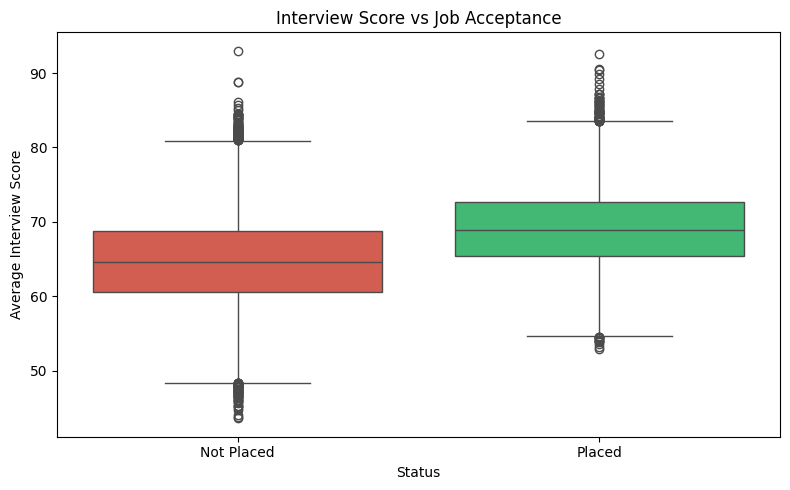

In [ ]:
df['avg_interview'] = df[['technical_score', 'aptitude_score', 'communication_score']].mean(axis=1)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='status', y='avg_interview', palette=['#e74c3c', '#2ecc71'])
plt.title('Interview Score vs Job Acceptance')
plt.xlabel('Status')
plt.ylabel('Average Interview Score')
plt.tight_layout()
plt.show()

##Insights


*   Placed candidates show higher median interview scores compared to Not Placed candidates

*   The interquartile range (IQR) for Placed candidates is narrower, indicating more consistent interview performance among those who accepted offers


*   Keep outliers as they provide meaningful business insights

###2. Skills Match vs Job Acceptance

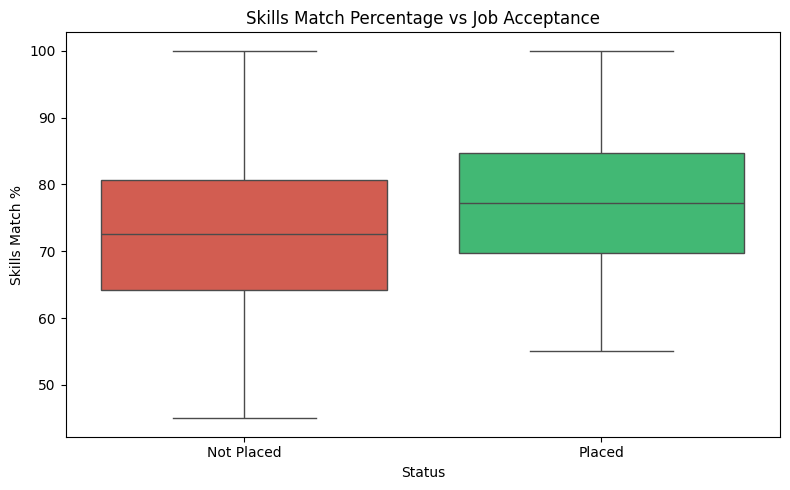

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='status', y='skills_match_percentage', palette=['#e74c3c', '#2ecc71'])
plt.title('Skills Match Percentage vs Job Acceptance')
plt.xlabel('Status')
plt.ylabel('Skills Match %')
plt.tight_layout()
plt.show()

##Insights


*   Placed candidates have significantly higher median skills match percentage compared to Not Placed candidates

*   The IQR for Placed candidates is higher, indicating that candidates with 70%+ skills match are more likely to accept offers


*   The Not Placed group shows lower median and wider spread, suggesting other factors also influence rejection

### 3. Company Tier vs Acceptance Rate

<Figure size 800x500 with 0 Axes>

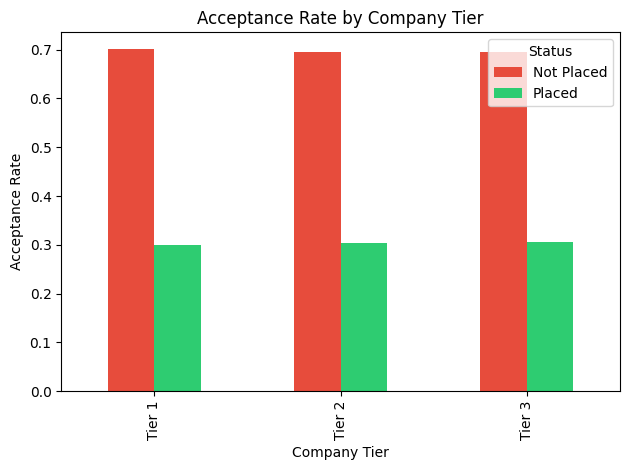

In [30]:
plt.figure(figsize=(8, 5))
pd.crosstab(df['company_tier'], df['status'], normalize='index').plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Acceptance Rate by Company Tier')
plt.xlabel('Company Tier')
plt.ylabel('Acceptance Rate')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##Insights


*   Tier 1 and Tier 2 companies show nearly equal acceptance rates (~30%), indicating candidates show similar preference for both tiers


*   Tier 3 companies show a slightly lower acceptance rate (~28%), suggesting a marginal decline in preference for lower-tier organizations



*   Other factors like role match, skills alignment, and CTC expectations likely play a more significant role in acceptance than company tier alone.

### 4. Experience vs Acceptance Rate

<Figure size 800x500 with 0 Axes>

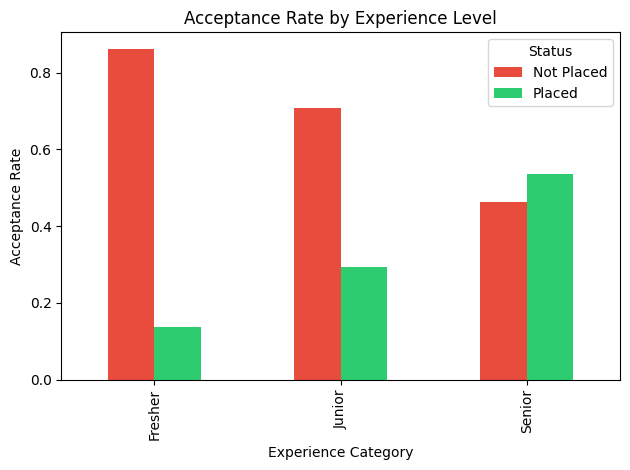

In [31]:
df['exp_cat'] = pd.cut(df['years_of_experience'], bins=[-1, 0, 2, 5, 20], labels=['Fresher', 'Junior', 'Senior', 'Expert'])

plt.figure(figsize=(8, 5))
pd.crosstab(df['exp_cat'], df['status'], normalize='index').plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Acceptance Rate by Experience Level')
plt.xlabel('Experience Category')
plt.ylabel('Acceptance Rate')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##Insights


*   Freshers and Junior-level candidates show similar acceptance rates (~30%), indicating entry-level candidates have comparable offer acceptance behavior

*   Senior-level candidates have a noticeably lower acceptance rate (~25%), suggesting experienced professionals are more selective in their job choices

### 5. Competition Level vs Job Acceptance

<Figure size 800x500 with 0 Axes>

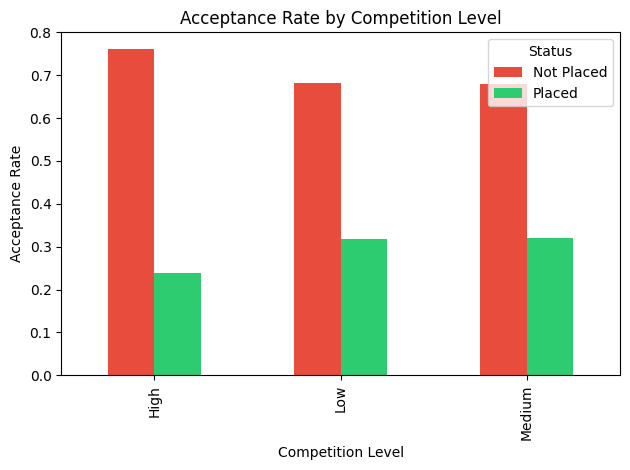

In [32]:
plt.figure(figsize=(8, 5))
pd.crosstab(df['competition_level'], df['status'], normalize='index').plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Acceptance Rate by Competition Level')
plt.xlabel('Competition Level')
plt.ylabel('Acceptance Rate')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##Insights


*   Candidates in Low competition environments show the highest acceptance rate (~32%), indicating less competitive markets lead to better offer conversion

*   The variation across competition levels is marginal (28-32%), suggesting competition level alone is not a primary driver of acceptance decisions

###6. Correlation Analysis

⚠️ status_enc not found, creating it...
Using columns for correlation: ['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'technical_score', 'aptitude_score', 'communication_score', 'skills_match_percentage', 'certifications_count', 'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa', 'status_enc']


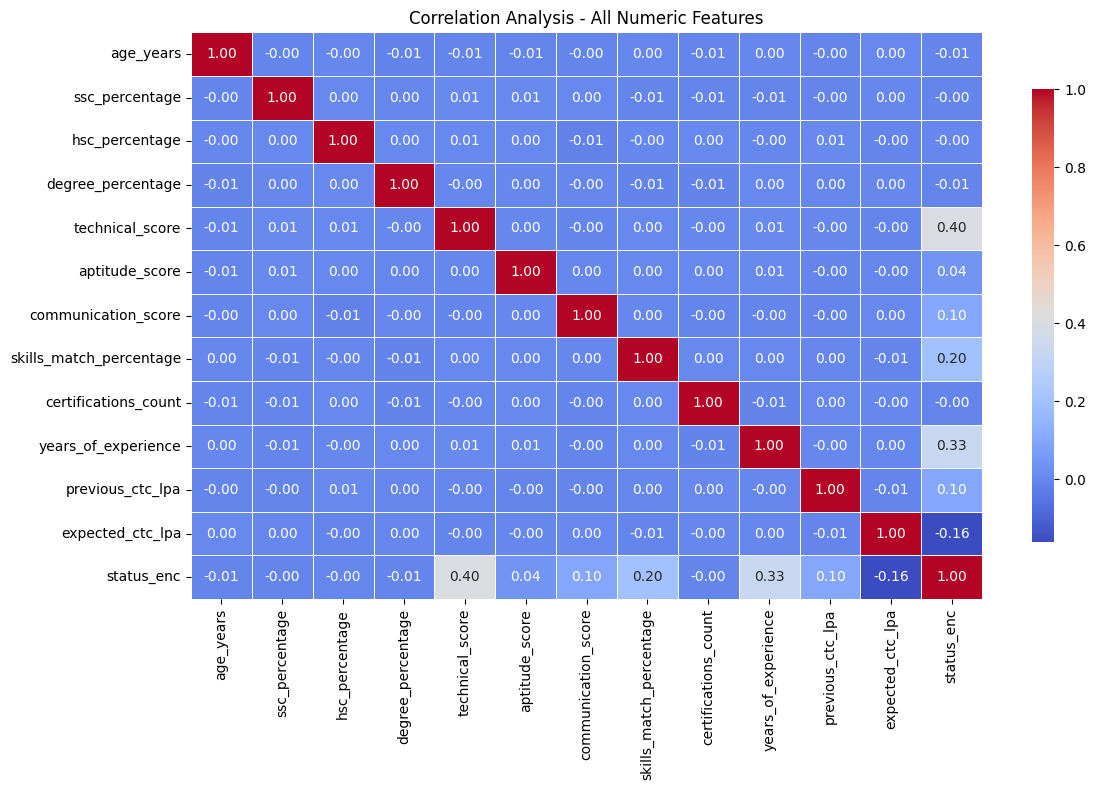

In [33]:
num_cols = ['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
            'technical_score', 'aptitude_score', 'communication_score',
            'skills_match_percentage', 'certifications_count', 'years_of_experience',
            'previous_ctc_lpa', 'expected_ctc_lpa']

# Add status_enc if it exists
if 'status_enc' in df.columns:
    num_cols.append('status_enc')
else:
    print("⚠️ status_enc not found, creating it...")
    df['status_enc'] = df['status'].map({'Placed': 1, 'Not Placed': 0})
    num_cols.append('status_enc')

# Check if all columns exist
available_cols = [col for col in num_cols if col in df.columns]
print(f"Using columns for correlation: {available_cols}")

plt.figure(figsize=(12, 8))
sns.heatmap(df[available_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Analysis - All Numeric Features')
plt.tight_layout()
plt.show()



##Insight

*   Skills match percentage is the strongest predictor of job acceptance, while academic and interview scores show weak correlation with placement outcomes, indicating that role alignment matters more than raw scores


### 7. Skills Match vs Interview Score

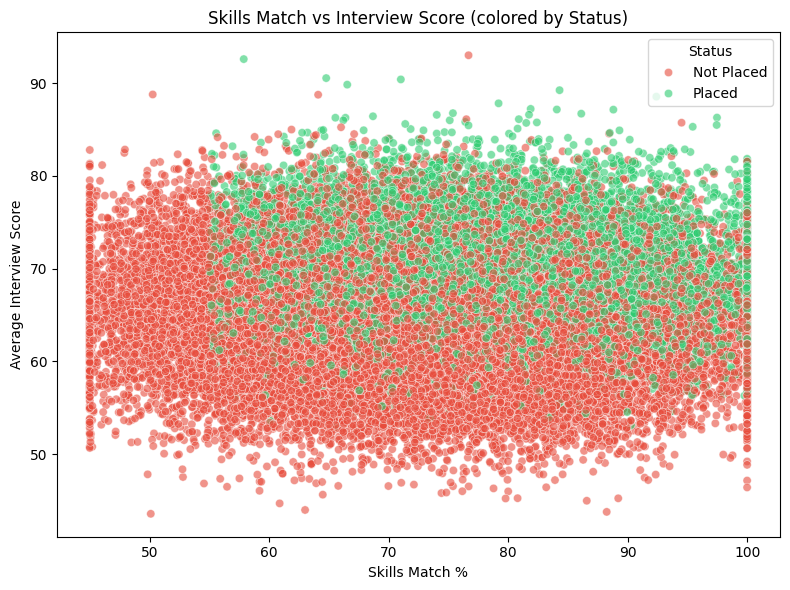

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='skills_match_percentage', y='avg_interview',
                hue='status', alpha=0.6, palette=['#e74c3c', '#2ecc71'])
plt.title('Skills Match vs Interview Score (colored by Status)')
plt.xlabel('Skills Match %')
plt.ylabel('Average Interview Score')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


##Insights


*   Placed candidates cluster in the high skills match (>70%) and moderate interview score (65-80) region, while Not Placed candidates dominate the low-low quadrant

*   Candidates with high interview scores but low skills match are still not placed, confirming skills alignment is more critical than interview performance alone


*   The diagonal separation between clusters indicates a strong linear relationship between skills match and interview scores, making them the two most critical factors for placement success


##Save Cleaned Dataset

In [35]:
df.to_csv('HR_Job_Placement_Cleaned.csv', index=False)
print(f"\n✅ Cleaned data saved! Shape: {df.shape}")
print(f"New features added: {len(df.columns) - 26}")  # 26 original columns

# Show sample
print("\nSample of cleaned data:")
print(df[['gender', 'status', 'avg_academic', 'avg_interview', 'exp_category', 'ctc_diff']].head(10))


✅ Cleaned data saved! Shape: (50124, 35)
New features added: 9

Sample of cleaned data:
   gender      status  avg_academic  avg_interview exp_category  ctc_diff
0    Male  Not Placed     74.920254      70.754233       Junior  2.275293
1    Male  Not Placed     68.650839      62.532418      Fresher  0.949584
2  Female      Placed     77.641017      70.175622       Junior -0.324979
3    Male  Not Placed     75.329142      64.539376      Fresher  7.850775
4    Male  Not Placed     69.021094      65.146274      Fresher  0.972919
5  Female      Placed     68.332356      59.665296       Junior -1.918530
6  Female      Placed     75.891144      67.568391       Junior -0.832504
7  Female      Placed     71.506796      69.482365       Senior -4.952279
8  Female      Placed     76.016935      74.186718       Junior -1.190206
9  Female  Not Placed     73.947321      58.392707       Junior -2.834123


##Feature Engineering

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# All categorical columns to encode (including engineered + original)
cat_cols_to_encode = [
    'exp_category', 'skills_level', 'academic_band', 'interview_performance',
    'gender', 'company_tier', 'job_role_match', 'competition_level',
    'bond_requirement', 'career_switch_willingness', 'relevant_experience',
    'relocation_willingness', 'internship_experience', 'layoff_history'
]

# Encode each column
for col in cat_cols_to_encode:
    if col in df.columns:
        df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
        print(f"✅ Encoded: {col}")

# Encode target
df['status_enc'] = le.fit_transform(df['status'])

print("\n✅ Label Encoding Complete!")

✅ Encoded: exp_category
✅ Encoded: skills_level
✅ Encoded: academic_band
✅ Encoded: interview_performance
✅ Encoded: gender
✅ Encoded: company_tier
✅ Encoded: job_role_match
✅ Encoded: competition_level
✅ Encoded: bond_requirement
✅ Encoded: career_switch_willingness
✅ Encoded: relevant_experience
✅ Encoded: relocation_willingness
✅ Encoded: internship_experience
✅ Encoded: layoff_history

✅ Label Encoding Complete!


##Target/Feature Assingment

In [37]:
X = df.drop(columns=['status', 'status_enc'], errors='ignore')
y = df['status_enc']

print(f"Features: {X.shape[1]} columns")
print(f"Target: {y.value_counts().to_dict()}")

Features: 47 columns
Target: {0: 34950, 1: 15174}


##Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class balance
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (40099, 47)
X_test: (10025, 47)
y_train: (40099,)
y_test: (10025,)


##Feature Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

# Identify only numerical columns
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Scale only numerical columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"✅ Scaled {len(num_cols)} numerical columns")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✅ Scaled 31 numerical columns
X_train_scaled shape: (40099, 47)
X_test_scaled shape: (10025, 47)


In [40]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,avg_academic,avg_interview,exp_category,skills_level,academic_band,interview_performance,ctc_diff,exp_cat,status_enc,exp_category_enc,skills_level_enc,academic_band_enc,interview_performance_enc,gender_enc,company_tier_enc,job_role_match_enc,competition_level_enc,bond_requirement_enc,career_switch_willingness_enc,relevant_experience_enc,relocation_willingness_enc,internship_experience_enc,layoff_history_enc
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,2,No,1,Willing,Relevant,3.530557,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed,74.920254,70.754233,Junior,Medium,High,Good,2.275293,Junior,0,1,2,1,2,1,2,1,2,0,1,1,0,0,0
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,1,Yes,0,Not Willing,Relevant,9.858155,10.807739,Tier 1,Matched,High,Required,0.0,No,0.0,Not Willing,Not Placed,68.650839,62.532418,Fresher,Medium,Medium,Average,0.949584,Fresher,0,0,2,3,0,1,0,0,0,1,0,1,0,1,0
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,1,Yes,1,Willing,Relevant,5.801817,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed,77.641017,70.175622,Junior,Medium,High,Good,-0.324979,Junior,1,1,2,1,2,0,2,1,1,0,1,1,0,1,0
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,2,No,0,Not Willing,Relevant,2.129805,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,Willing,Not Placed,75.329142,64.539376,Fresher,Medium,High,Average,7.850775,Fresher,0,0,2,1,0,1,1,0,1,0,0,1,1,0,1
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,1,No,0,Willing,Not Relevant,7.948314,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed,69.021094,65.146274,Fresher,High,Medium,Average,0.972919,Fresher,0,0,0,3,0,1,1,0,2,0,1,0,1,0,0


##Balancing Dataset - SMOTE

In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Get all numeric/encoded columns
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ SMOTE Complete!")
print(f"Before: {X_train_scaled.shape}")
print(f"After: {X_train_bal.shape}")
print(f"\nBalanced target distribution:")
print(y_train_bal.value_counts())

✅ SMOTE Complete!
Before: (40099, 31)
After: (55920, 31)

Balanced target distribution:
status_enc
0    27960
1    27960
Name: count, dtype: int64


##Model Training

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [43]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)

In [44]:
# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_bal, y_train_bal)
y_pred_dt = dt.predict(X_test_scaled)

In [45]:
# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test_scaled)

##Model Evaluation

In [46]:
models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

results = []

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc:.4f}")



Logistic Regression:
  Accuracy:  0.8569
  Precision: 0.7212
  Recall:    0.8593
  F1-Score:  0.7842
  ROC-AUC:   0.8576

Decision Tree:
  Accuracy:  0.8374
  Precision: 0.7181
  Recall:    0.7621
  F1-Score:  0.7395
  ROC-AUC:   0.8161

Random Forest:
  Accuracy:  0.8939
  Precision: 0.8280
  Recall:    0.8198
  F1-Score:  0.8238
  ROC-AUC:   0.8729


In [47]:
# Calculate accuracies
print("="*50)
print("MODEL ACCURACY COMPARISON")
print("="*50)

# Logistic Regression
print(f"\nLogistic Regression:")
print(f"  Train: {accuracy_score(y_train_bal, lr.predict(X_train_bal)):.4f}")
print(f"  Test:  {accuracy_score(y_test, lr.predict(X_test_scaled)):.4f}")

# Decision Tree
print(f"\nDecision Tree:")
print(f"  Train: {accuracy_score(y_train_bal, dt.predict(X_train_bal)):.4f}")
print(f"  Test:  {accuracy_score(y_test, dt.predict(X_test_scaled)):.4f}")

# Random Forest
print(f"\nRandom Forest:")
print(f"  Train: {accuracy_score(y_train_bal, rf.predict(X_train_bal)):.4f}")
print(f"  Test:  {accuracy_score(y_test, rf.predict(X_test_scaled)):.4f}")

MODEL ACCURACY COMPARISON

Logistic Regression:
  Train: 0.8755
  Test:  0.8569

Decision Tree:
  Train: 1.0000
  Test:  0.8374

Random Forest:
  Train: 1.0000
  Test:  0.8939


In [48]:
# RESULTS TABLE
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


SUMMARY TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.856858   0.721239 0.859308  0.784243 0.857551
      Decision Tree  0.837406   0.718100 0.762109  0.739450 0.816104
      Random Forest  0.893865   0.827953 0.819769  0.823841 0.872903


In [49]:
# BEST MODEL
best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")


🏆 Best Model: Random Forest
   F1-Score: 0.8238
   Accuracy: 0.8939


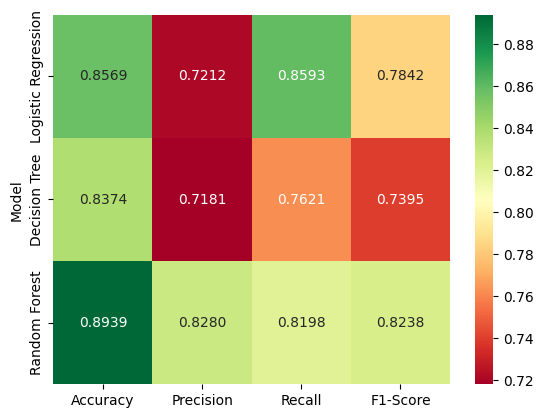

In [50]:
sns.heatmap(pd.DataFrame([{
    'Model': name,
    'Accuracy': accuracy_score(y_test, pred),
    'Precision': precision_score(y_test, pred),
    'Recall': recall_score(y_test, pred),
    'F1-Score': f1_score(y_test, pred)
} for name, pred in models.items()]).set_index('Model'), annot=True, fmt='.4f', cmap='RdYlGn').figure.show()

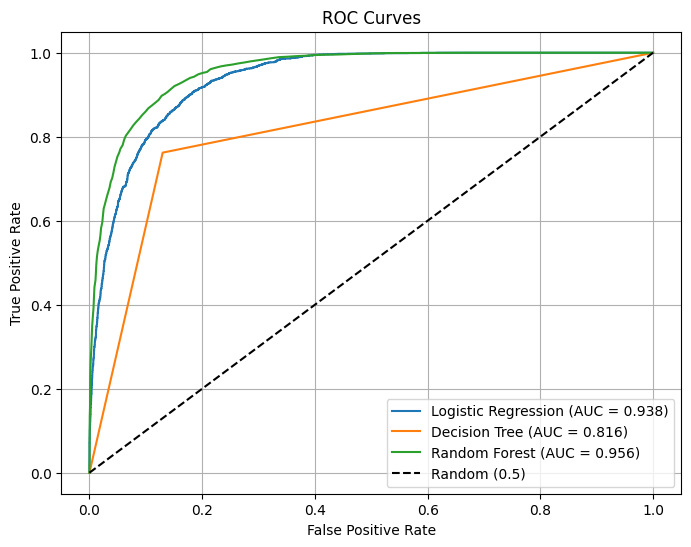

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': lr.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': dt.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf.predict_proba(X_test_scaled)[:, 1]
}

plt.figure(figsize=(8, 6))
for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()
plt.show()

##Save the model

In [52]:
import joblib
import pickle

# Save model and scaler
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature columns (IMPORTANT!)
feature_columns = X_train_num.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("✅ Random Forest model saved as 'random_forest_model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")
print("✅ Feature columns saved as 'feature_columns.pkl'")

✅ Random Forest model saved as 'random_forest_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Feature columns saved as 'feature_columns.pkl'
